# Medical Insurance Cost Prediction using Multiple Linear Regression
**AI-ML Assignment 1**

Dataset: [Medical Cost Personal Insurance Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## Task 1: Data Understanding
1. Load the dataset using Pandas
2. Display the first five records
3. Identify numerical features, categorical features, and the target variable

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
numerical_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]
target_variable = "charges"

print("Numerical features   :", numerical_features)
print("Categorical features :", categorical_features)
print("Target variable      :", target_variable)

Numerical features   : ['age', 'bmi', 'children']
Categorical features : ['sex', 'smoker', 'region']
Target variable      : charges


## Task 2: Data Preprocessing
- Check for missing values
- Encode categorical variables (sex, smoker, region)
- Split the dataset into 80% training and 20% testing

In [4]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df_encoded = df.copy()

# Binary encoding
df_encoded["sex"] = df_encoded["sex"].map({"male": 0, "female": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})

# One-hot encoding for region (more than 2 categories)
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [6]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])

Training set size: 1070
Testing set size : 268


## Task 3: Model Development
Build a Multiple Linear Regression model using: Age, Sex, BMI, Children, Smoker, Region  
Target: Charges

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("Intercept:", model.intercept_)
coef_df

Intercept: -11949.810741967713


,Feature,Coefficient
0,age,256.975706
1,sex,18.591692
2,bmi,337.092552
3,children,425.278784
4,smoker,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## Task 4: Model Evaluation
Evaluate using MAE, MSE, R² Score, and an Actual vs Predicted scatter plot

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R2 Score: 0.7836


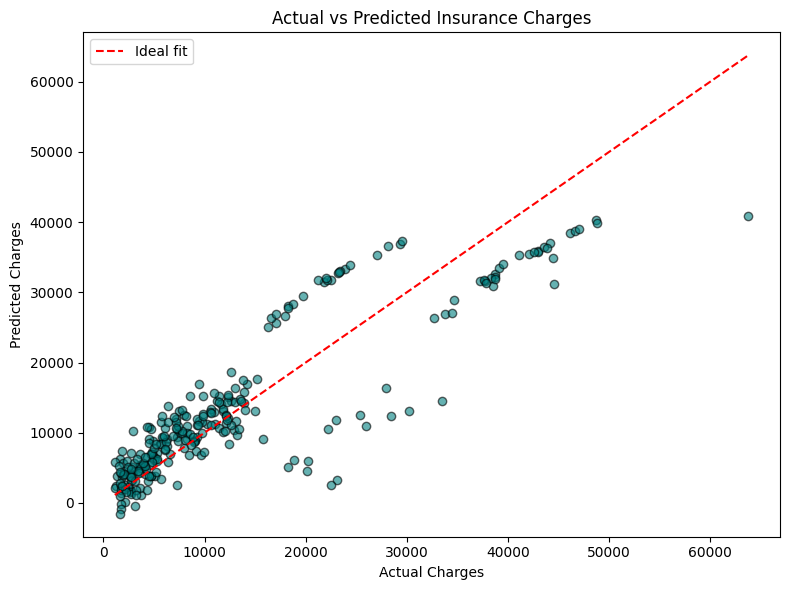

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Ideal fit")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

**Observations:**

1. The model achieves a reasonably high R² score, meaning a large portion of the variance in insurance charges can be explained by age, sex, BMI, children, smoker status, and region.
2. Points lie close to the diagonal 'ideal fit' line for lower charge values, but the model under-predicts for customers with very high actual charges (mostly smokers), showing higher error at the extremes.
3. The 'smoker' feature has by far the largest coefficient magnitude, confirming it is the strongest driver of insurance cost in this model.

## Task 5: Conclusion

This project built a Multiple Linear Regression model to predict medical insurance charges using age, sex, BMI, number of children, smoking status, and region. The model achieved an R² score of approximately 0.78, indicating a reasonably good fit to the test data. Smoking status emerged as the single strongest predictor of charges, followed by age and BMI, while sex and region had comparatively minor effects. These findings align with real-world expectations, since smokers and older, higher-BMI individuals generally carry greater health risk and therefore higher insurance costs. A key limitation of Linear Regression here is its assumption of a linear relationship between features and charges; in reality, costs rise sharply and non-linearly for high-risk groups such as smokers, which the model cannot fully capture. A non-linear approach (e.g. polynomial regression or tree-based models) may fit this data better.